In [18]:
import pandas as pd
import numpy as np

import shap
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
best_model = joblib.load(
    "../models/best_fraud_model.pkl"
)

In [20]:
fraud = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

In [21]:
y = fraud["class"]

X = fraud.drop(
    "class",
    axis=1
)

In [22]:
X = X.drop(
    ["user_id", "device_id"],
    axis=1,
    errors="ignore"
)

In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

In [24]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [25]:
importance.head(10)

,Feature,Importance
10,transaction_velocity,0.228617
6,hour_of_day,0.223135
3,lower_bound_ip_address,0.081612
0,purchase_value,0.059941
1,age,0.051969
7,day_of_week,0.050229
2,ip_address,0.049982
8,user_tx_count,0.039676
12,source_SEO,0.035222
11,source_Direct,0.034300


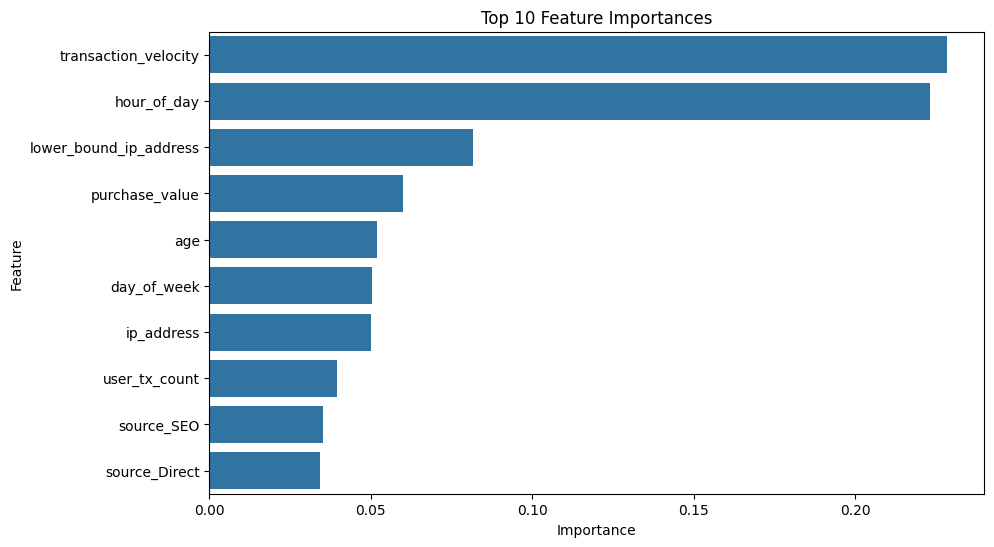

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importances"
)

plt.show()

In [27]:
plt.savefig(
    "../models/top10_feature_importance.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [28]:
explainer = shap.TreeExplainer(
    best_model
)

In [29]:
print(type(X))

<class 'pandas.core.frame.DataFrame'>


In [30]:
from sklearn.model_selection import train_test_split

y = fraud['class']

X = fraud.drop(
    ['class', 'device_id'],
    axis=1,
    errors='ignore'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
print(X_test.shape)
print(y_test.shape)

(2909, 26)
(2909,)


In [ ]:
shap_values = explainer.shap_values(
    X_test
)

In [ ]:
shap_values = shap_values[1]

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

In [ ]:
plt.savefig(
    "../models/shap_summary_plot.png",
    bbox_inches="tight"
)

In [ ]:
y_pred = best_model.predict(
    X_test
)

In [ ]:
tp_idx = np.where(
    (y_test == 1) &
    (y_pred == 1)
)[0][0]

In [ ]:
fp_idx = np.where(
    (y_test == 0) &
    (y_pred == 1)
)[0][0]

In [ ]:
fp_idx = np.where(
    (y_test == 0) &
    (y_pred == 1)
)[0][0]

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[tp_idx],
    X_test.iloc[tp_idx]
)

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[fp_idx],
    X_test.iloc[fp_idx]
)

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[fn_idx],
    X_test.iloc[fn_idx]
)

In [ ]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Importance": np.abs(shap_values).mean(axis=0)
})

In [ ]:
shap_importance = shap_importance.sort_values(
    by="SHAP Importance",
    ascending=False
)

In [ ]:
shap_importance.head(10)